Load dataset

In [279]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,MAX_NOISE,RXPACC
0,0,3.90,745,18712,10250,11576,11855,967,611
1,0,0.66,749,11239,6313,4712,18968,1133,447
2,1,7.86,746,4355,5240,3478,14699,894,723
3,1,3.48,750,8502,8416,5890,8748,1127,1024
4,0,1.19,746,17845,18095,12058,11380,1744,276


Extract NLOS column and put into y as class labels

In [280]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

Split dataset into training and testing with 70:30 ratio


In [281]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print(X_train.shape)
print(X_test.shape)

(29400, 8)
(12600, 8)


Scale features with StandardScaler

In [282]:
from sklearn.preprocessing import StandardScaler

print("Before Scaling:")
print(X_train.shape)
print(X_train.head())

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("After Scaling:")
print(X_train.shape)
print(X_train[0:5])

Before Scaling:
(29400, 8)
       RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  CIR_PWR  MAX_NOISE  RXPACC
32141   3.38     744     4796    16013    19357    10498        831     412
10895   4.20     742     1714     5390     3405     6967       1134    1024
2087    9.20     739     4056     3165     2825     8330       1080    1025
35565   5.65     742     2162      623     1384     4437        970    1024
4351    1.88     751    11704     6288     6121    11470       1494     276
After Scaling:
(29400, 8)
[[-0.19113517 -0.3677422  -0.61759027  0.7355948   1.79475279  0.14728
  -0.83892358 -0.66476221]
 [ 0.15566223 -0.81861151 -1.18923249 -0.96721231 -1.18312471 -0.57364969
  -0.31824922  1.32534983]
 [ 2.2702805  -1.49491548 -0.75484375 -1.32386728 -1.29139759 -0.29536389
  -0.41104267  1.32860164]
 [ 0.76890153 -0.81861151 -1.10613849 -1.73133557 -1.56039969 -1.09020367
  -0.60006636  1.32534983]
 [-0.82552065  1.21030039  0.66368958 -0.82326796 -0.67610896  0.34573473
   0.30037379 -1

Train model using different C hyperparameter values

Text(0, 0.5, 'Accuracy')

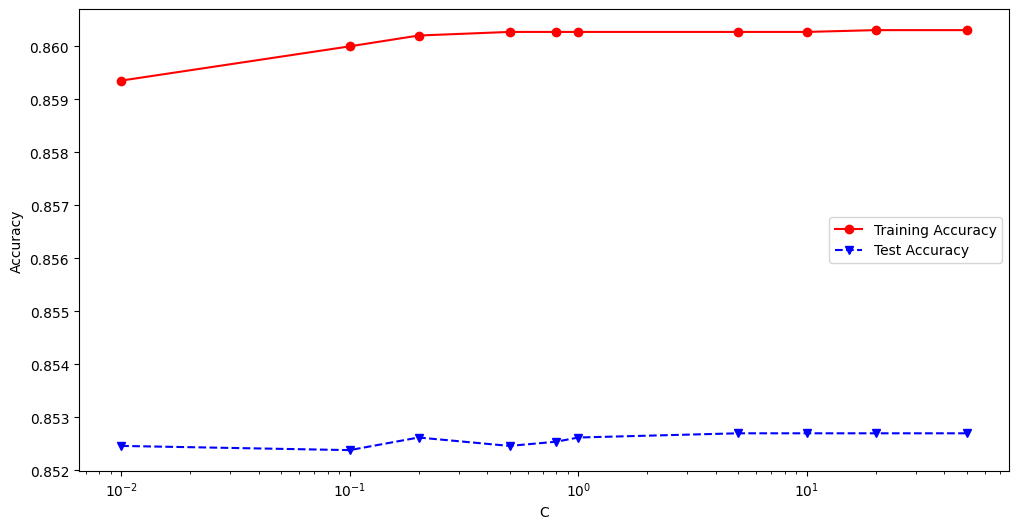

In [283]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

C = [0.01, 0.1, 0.2, 0.5, 0.8, 1, 5, 10, 20, 50]

LRTrainAcc = []
LRTestAcc = []

for c in C:
    # Create and train the Logistic Regression model
    logreg = LogisticRegression(C=c)
    logreg.fit(X_train, y_train)

    # Predict on the training set
    y_pred_train = logreg.predict(X_train)
    # Predict on the test set
    y_pred_test = logreg.predict(X_test)

    # Evaluate the performance
    train_accuracy_logreg = accuracy_score(y_train, y_pred_train)
    test_accuracy_logreg = accuracy_score(y_test, y_pred_test)

    LRTrainAcc.append(train_accuracy_logreg)
    LRTestAcc.append(test_accuracy_logreg)
    

fig, (ax1) = plt.subplots(1, 1, figsize=(12,6))
ax1.plot(C, LRTrainAcc, 'ro-', C, LRTestAcc,'bv--')
ax1.legend(['Training Accuracy','Test Accuracy'])
ax1.set_xlabel('C')
ax1.set_xscale('log')
ax1.set_ylabel('Accuracy')

Logistic Regression Accuracy: 85.27%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      6288
           1       0.89      0.80      0.84      6312

    accuracy                           0.85     12600
   macro avg       0.86      0.85      0.85     12600
weighted avg       0.86      0.85      0.85     12600

Confusion Matrix:
[[5693  595]
 [1261 5051]]


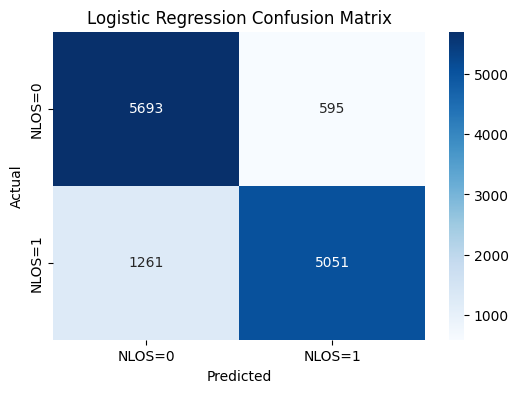

In [284]:
print("Logistic Regression Accuracy: {:.2f}%".format(test_accuracy_logreg * 100))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

# 4. Compute and display the confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(cm_logreg)

plt.figure(figsize=(6,4))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [285]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Assuming your training features are in X_train (with the target dropped)
# # If not, create a new DataFrame for feature importance analysis:
# # X_train_no_target = X_train.drop(columns=["NLOS"])
# # Otherwise, if X_train is already defined without "NLOS":
# X_train_no_target = X_train

# # Extract coefficients from the logistic regression model.
# # For binary classification, logreg.coef_ returns a 2D array of shape (1, n_features)
# coefficients = pd.Series(logreg.coef_[0], index=X_train_no_target.columns)

# # Sort coefficients by absolute value (largest magnitude first)
# coefficients_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

# plt.figure(figsize=(8,5))
# ax = sns.barplot(x=coefficients_sorted.values, 
#                  y=coefficients_sorted.index, 
#                  hue=coefficients_sorted.index, 
#                  palette="viridis", 
#                  dodge=False)
# if ax.get_legend() is not None:
#     ax.get_legend().remove()

# plt.xlabel("Coefficient Value")
# plt.ylabel("Feature")
# plt.title("Logistic Regression Coefficients (Feature Importance)")
# plt.show()


In [286]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
# from sklearn.cluster import DBSCAN
# from sklearn.decomposition import PCA

# # -----------------------------
# # Remove Outliers (Noise) Detected by DBSCAN
# # -----------------------------

# # Add DBSCAN cluster labels to the dataframe
# df["cluster"] = clusters

# # Separate out the noise (-1) from valid data
# df_filtered = df[df["cluster"] != -1].drop(columns=["cluster"])  # Keep only non-noise points

# # Re-define X and y after outlier removal
# X_filtered = df_filtered.drop(columns=["NLOS"])
# y_filtered = df_filtered["NLOS"]

# # Rescale the filtered dataset
# scaler = StandardScaler()
# X_filtered_scaled = scaler.fit_transform(X_filtered)

# # -----------------------------
# # Train Logistic Regression Again After Noise Removal
# # -----------------------------

# # Split dataset after noise removal
# X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
#     X_filtered, y_filtered, test_size=0.3, random_state=111)

# # Train Logistic Regression (After Outlier Removal)
# logreg_after = LogisticRegression(random_state=111, max_iter=500)
# logreg_after.fit(X_train_filtered, y_train_filtered)
# y_pred_after = logreg_after.predict(X_test_filtered)
# accuracy_after = accuracy_score(y_test_filtered, y_pred_after)

# # -----------------------------
# # Compare Accuracy Before and After Outlier Removal
# # -----------------------------
# accuracy_results = pd.DataFrame({
#     "Condition": ["Before Outlier Removal", "After Outlier Removal"],
#     "Accuracy": [round(accuracy_logreg, 4), round(accuracy_after, 4)]
# })

# print("\nAccuracy Comparison:")
# print(accuracy_results)

# # -----------------------------
# # Visualize DBSCAN Clusters Before and After Noise Removal
# # -----------------------------

# # PCA Projection for Visualization
# pca = PCA(n_components=2)
# X_pca_before = pca.fit_transform(X_scaled)  # Before noise removal
# X_pca_after = pca.fit_transform(X_filtered_scaled)  # After noise removal

# # Create DataFrames for visualization
# pca_df_before = pd.DataFrame(X_pca_before, columns=["PCA1", "PCA2"])
# pca_df_before["cluster"] = clusters

# pca_df_after = pd.DataFrame(X_pca_after, columns=["PCA1", "PCA2"])
# pca_df_after["cluster"] = DBSCAN(eps=eps_value, min_samples=min_samples).fit_predict(X_filtered_scaled)

# # Plot Before Noise Removal
# plt.figure(figsize=(8,6))
# sns.scatterplot(data=pca_df_before, x="PCA1", y="PCA2", hue="cluster", palette="viridis", s=60)
# plt.title("DBSCAN Clusters Before Noise Removal")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(title="Cluster")
# plt.show()

# # Plot After Noise Removal
# plt.figure(figsize=(8,6))
# sns.scatterplot(data=pca_df_after, x="PCA1", y="PCA2", hue="cluster", palette="viridis", s=60)
# plt.title("DBSCAN Clusters After Noise Removal")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(title="Cluster")
# plt.show()

In [287]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
# from sklearn.cluster import KMeans
# from sklearn.decomposition import PCA

# # -----------------------------
# # Apply K-Means for Clustering (Instead of DBSCAN)
# # -----------------------------

# kmeans = KMeans(n_clusters=3, random_state=111, n_init=10)  # Adjust the number of clusters as needed
# df["cluster"] = kmeans.fit_predict(X_scaled)  # Assign clusters

# # Find the smallest cluster (assume it contains outliers)
# cluster_counts = df["cluster"].value_counts()
# smallest_cluster = cluster_counts.idxmin()  # Cluster with the fewest data points

# # Remove outliers: Keep only points that are **not** in the smallest cluster
# df_filtered = df[df["cluster"] != smallest_cluster].drop(columns=["cluster"])  # Keep valid points

# # Re-define X and y after outlier removal
# X_filtered = df_filtered.drop(columns=["NLOS"])
# y_filtered = df_filtered["NLOS"]

# # Rescale the filtered dataset
# scaler = StandardScaler()
# X_filtered_scaled = scaler.fit_transform(X_filtered)

# # -----------------------------
# # Train Logistic Regression Again After Noise Removal
# # -----------------------------

# # Split dataset after noise removal
# X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
#     X_filtered, y_filtered, test_size=0.3, random_state=111)

# # Train Logistic Regression (After Outlier Removal with K-Means)
# logreg_after = LogisticRegression(random_state=111, max_iter=500)
# logreg_after.fit(X_train_filtered, y_train_filtered)
# y_pred_after = logreg_after.predict(X_test_filtered)
# accuracy_after = accuracy_score(y_test_filtered, y_pred_after)

# # -----------------------------
# # Compare Accuracy Before and After Outlier Removal
# # -----------------------------
# accuracy_results = pd.DataFrame({
#     "Condition": ["Before Outlier Removal", "After Outlier Removal (K-Means)"],
#     "Accuracy": [round(accuracy_logreg, 4), round(accuracy_after, 4)]
# })

# print("\nAccuracy Comparison with K-Means:")
# print(accuracy_results.to_string(index=False))  # Print without row index

# # -----------------------------
# # Visualize K-Means Clusters Before and After Outlier Removal
# # -----------------------------

# # PCA Projection for Visualization
# pca = PCA(n_components=2)
# X_pca_before = pca.fit_transform(X_scaled)  # Before noise removal
# X_pca_after = pca.fit_transform(X_filtered_scaled)  # After noise removal

# # Create DataFrames for visualization
# pca_df_before = pd.DataFrame(X_pca_before, columns=["PCA1", "PCA2"])
# pca_df_before["cluster"] = kmeans.labels_

# pca_df_after = pd.DataFrame(X_pca_after, columns=["PCA1", "PCA2"])
# pca_df_after["cluster"] = KMeans(n_clusters=3, random_state=111, n_init=10).fit_predict(X_filtered_scaled)

# # Plot Before Outlier Removal
# plt.figure(figsize=(8,6))
# sns.scatterplot(data=pca_df_before, x="PCA1", y="PCA2", hue="cluster", palette="viridis", s=60)
# plt.title("K-Means Clusters Before Noise Removal")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(title="Cluster")
# plt.show()

# # Plot After Outlier Removal
# plt.figure(figsize=(8,6))
# sns.scatterplot(data=pca_df_after, x="PCA1", y="PCA2", hue="cluster", palette="viridis", s=60)
# plt.title("K-Means Clusters After Noise Removal")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(title="Cluster")
# plt.show()
